In [1]:
import importlib
import NeuralNetwork

importlib.reload(NeuralNetwork)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device being used: {device.type}")

device being used: cpu


In [3]:
# Define a transform to convert images to PyTorch tensors
transform = transforms.ToTensor()

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [4]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [5]:
# Create a DataLoader for batching
batch_size = 256 if device.type == "cuda" else 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [6]:
# Create model and train
model = NeuralNetwork(hidden_sizes=[512, 256, 128], device=device)

In [7]:
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=3)

Epoch 3/3: 100%|██████████| 3750/3750 [00:36<00:00, 102.54it/s]


,train_loss,val_loss,val_acc
epoch,,,
1,0.340806,0.163010,0.953812
2,0.267567,0.154375,0.959125
3,0.258462,0.132848,0.963417


In [8]:
train_acc = model.accuracy(train_loader)
val_acc = model.accuracy(val_loader)

100%|██████████| 750/750 [00:05<00:00, 146.18it/s]


In [9]:
print(f"Train: {(train_acc*100):.2f}%, Validation: {(val_acc*100):.2f}%")

Train: 96.61%, Validation: 96.34%


## Prune Neurons and Retrain

In [10]:
from IPython.display import clear_output
import copy

max_prune_rounds = 2
prune_fraction = 0.2
regrowth_fraction = 0.1
min_val_acc = 0.9

metrics_history = []
prune_history = []

original_model = copy.deepcopy(model)
pruned_model = copy.deepcopy(original_model)

for round_idx in range(max_prune_rounds):
    clear_output(wait=True)
    print(f"\n--- Pruning round {round_idx+1}/{max_prune_rounds} ---")

    print("Getting layer data:")
    layer_data = pruned_model.get_layer_data(train_loader)

    importance_scores = pruned_model.compute_neuron_importance(layer_data=layer_data)

    prune_history.append(importance_scores)

    pruned_model.prune_hidden_neurons(importance_scores=importance_scores, prune_rate=prune_fraction, alpha=0.7, regrow_frac=regrowth_fraction)

    print("Retraining:")
    metrics = pruned_model.train_model(train_loader, val_loader, epochs=1, lr=0.01)
    metrics_history.append(metrics)

    val_acc = metrics['val_acc'].iloc[-1]
    print(f"Validation accuracy after pruning round {round_idx+1}: {val_acc:.4f}")

    if val_acc < min_val_acc:
        print("Validation accuracy below threshold. Stopping pruning")
        break


--- Pruning round 2/2 ---
Getting layer data:


100%|██████████| 3000/3000 [00:17<00:00, 166.71it/s]


Retraining:


Epoch 1/1: 100%|██████████| 3750/3750 [00:37<00:00, 100.64it/s]

Validation accuracy after pruning round 2: 0.9636


In [11]:
for round_idx, metrics in enumerate(metrics_history, start=1):
    print(f"--- Round {round_idx} ---")
    final_val_acc = metrics['val_acc'].iloc[-1]
    print(f"Final validation accuracy: {final_val_acc:.5f}")

--- Round 1 ---
Final validation accuracy: 0.96192
--- Round 2 ---
Final validation accuracy: 0.96358


In [12]:
for key, value in layer_data.items():
    print(value['post_activation'].shape)

torch.Size([192000, 420])
torch.Size([192000, 210])
torch.Size([192000, 105])
torch.Size([192000, 10])


## Activation analysis and Neuron Clustering

In [13]:
def neuron_correlation(post_activations):
    """
    post_activations: tensor of shape [num_samples, num_neurons]
    returns: [num_neurons, num_neurons] correlation matrix
    """

    X = post_activations - post_activations.mean(dim=0, keepdim=True)
    cov = X.T @ X / (X.shape[0] - 1)
    std = post_activations.std(dim=0, keepdim=True)
    corr = cov / (std.T @ std)
    return corr

In [14]:
layer_data_post_pruning = pruned_model.get_layer_data(train_loader)

100%|██████████| 3000/3000 [00:22<00:00, 134.30it/s]


In [15]:
print(layer_data_post_pruning.keys())

dict_keys(['layer_0', 'layer_1', 'layer_2', 'layer_3'])


In [16]:
from scipy.cluster.hierarchy import linkage, fcluster

hidden_layers = [k for k in layer_data_post_pruning.keys() if 'layer_' in k]

all_neuron_activations = []
for layer_name in hidden_layers:
    acts = layer_data_post_pruning[layer_name]['post_activation']
    all_neuron_activations.append(acts)

all_neuron_activations = torch.cat(all_neuron_activations, dim=1)

layer_mapping = []
start_idx = 0
for layer_name in hidden_layers:
    n_neurons = layer_data_post_pruning[layer_name]['post_activation'].shape[1]
    end_idx = start_idx + n_neurons
    layer_mapping.append((layer_name, start_idx, end_idx))
    start_idx = end_idx

neurons_for_clustering = all_neuron_activations.T.numpy()

Z = linkage(neurons_for_clustering, method='ward', metric='euclidean')

n_clusters = 8
clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

print(f"Total neurons clustered: {neurons_for_clustering.shape[0]}")
print(f"Clusters assigned: {np.unique(clusters)}")

Total neurons clustered: 612
Clusters assigned: [1 2 3 4 5 6 7 8]


In [17]:
def cluster_criticality(model, cluster_indices, layer_mapping, data_loader, device=None):
    """
    Computes the impact of ablating a neuron cluster across all hidden layers.

    Args:
        model: trained NeuralNetwork instance
        cluster_indices: list or array of global neuron indices in the cluster
        layer_mapping: list of tuples [(layer_name, start_idx, end_idx), ...] 
                       mapping global neuron indices to layers
        data_loader: DataLoader for evaluation (val_loader)
        device: torch device

    Returns:
        accuracy_drop: relative drop in accuracy after ablating the cluster
    """
    device = device or model.device
    model.eval()
    
    # Original accuracy
    orig_acc = model.accuracy(data_loader)
    
    # Backup weights and biases for all layers
    linear_indices = [i for i, l in enumerate(model.layer_stack) if isinstance(l, nn.Linear)]
    layer_backups = {}
    for layer_name, start_idx, end_idx in layer_mapping:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]
        layer_backups[layer_name] = {
            'weight': layer.weight.data.clone(),
            'bias': layer.bias.data.clone()
        }
    
    # Ablate neurons per layer
    for layer_name, start_idx, end_idx in layer_mapping:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]

        # Compute local indices for neurons in this layer
        local_indices = [i - start_idx for i in cluster_indices if start_idx <= i < end_idx]
        if not local_indices:
            continue

        # Zero out weights and biases
        layer.weight.data[local_indices, :] = 0
        layer.bias.data[local_indices] = 0

        # Update next layer input weights
        if layer_idx + 1 < len(linear_indices):
            next_layer = model.layer_stack[linear_indices[layer_idx + 1]]
            next_layer.weight.data[:, local_indices] = 0

    # Accuracy after ablation
    acc_after = model.accuracy(data_loader)

    # Restore all layers
    for layer_name, start_idx, end_idx in layer_mapping:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]
        layer.weight.data = layer_backups[layer_name]['weight']
        layer.bias.data = layer_backups[layer_name]['bias']

    accuracy_drop = orig_acc - acc_after
    return accuracy_drop

In [29]:
from collections import defaultdict

def cluster_criticality_per_class(model, cluster_indices, layer_mapping, data_loader, cluster_id, device=None, ):
    """
    Computes per-class impact of ablating a neuron cluster using model.predict.

    Args:
        model: trained NeuralNetwork instance
        cluster_indices: list of global neuron indices in the cluster
        layer_mapping: list of tuples [(layer_name, start_idx, end_idx), ...]
        data_loader: DataLoader for evaluation
        device: torch device

    Returns:
        class_acc_drop: dict {class_label: accuracy_drop}
    """
    device = device or model.device
    model.eval()

    # Get all labels
    all_labels = []
    for _, y in data_loader:
        all_labels.append(y)
    all_labels = torch.cat(all_labels).to(device)

    clear_output(wait=True)
    print(f"\n--- Calculating pre and post-ablation accuracy for cluster {cluster_id} ---")
    # Original predictions and per-class accuracy
    orig_preds = model.predict(data_loader)
    orig_preds = orig_preds.to(device)

    class_total = defaultdict(int)
    class_correct = defaultdict(int)
    for t, p in zip(all_labels, orig_preds):
        class_total[int(t)] += 1
        if t == p:
            class_correct[int(t)] += 1
    orig_acc_per_class = {cls: class_correct[cls]/class_total[cls] for cls in class_total}

    # Backup weights/biases
    linear_indices = [i for i, l in enumerate(model.layer_stack) if isinstance(l, torch.nn.Linear)]
    layer_backups = {}
    for layer_name, start_idx, end_idx in layer_mapping:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]
        layer_backups[layer_name] = {
            'weight': layer.weight.data.clone(),
            'bias': layer.bias.data.clone()
        }

    # Ablate neurons
    for layer_name, start_idx, end_idx in layer_mapping:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]

        local_indices = [i - start_idx for i in cluster_indices if start_idx <= i < end_idx]
        if not local_indices:
            continue

        layer.weight.data[local_indices, :] = 0
        layer.bias.data[local_indices] = 0

        # Zero out next layer input weights
        if layer_idx + 1 < len(linear_indices):
            next_layer = model.layer_stack[linear_indices[layer_idx + 1]]
            next_layer.weight.data[:, local_indices] = 0

    # Predictions after ablation
    ablated_preds = model.predict(data_loader).to(device)
    class_correct_after = defaultdict(int)
    for t, p in zip(all_labels, ablated_preds):
        if t == p:
            class_correct_after[int(t)] += 1
    acc_per_class_after = {cls: class_correct_after[cls]/class_total[cls] for cls in class_total}

    # Restore weights/biases
    for layer_name in layer_backups:
        layer_idx = int(layer_name.split('_')[1])
        linear_layer_idx = linear_indices[layer_idx]
        layer = model.layer_stack[linear_layer_idx]
        layer.weight.data = layer_backups[layer_name]['weight']
        layer.bias.data = layer_backups[layer_name]['bias']

    return {
        'pre': orig_acc_per_class,
        'post': acc_per_class_after
    }

In [33]:
cluster_map = defaultdict(list)
for neuron_idx, cluster_id in enumerate(clusters):
    cluster_map[cluster_id].append(neuron_idx)

cluster_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    per_class_acc = cluster_criticality_per_class(
        pruned_model,
        neuron_indices,
        layer_mapping,
        val_loader,
        cluster_id,
        device=device
    )
    cluster_results[cluster_id] = per_class_acc


--- Calculating pre and post-ablation accuracy for cluster 1 ---


100%|██████████| 750/750 [00:04<00:00, 162.84it/s]


In [43]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster_accuracy_bars(cluster_results, target_labels=None, n_cols=4, figsize_per_plot=(4,3)):
    """
    Plots per-cluster pre- vs post-ablation accuracy as bars per class.

    Args:
        cluster_results: dict of dicts {cluster_id: {'pre': {cls: acc}, 'post': {cls: acc}}}
        target_labels: list of class labels in order (optional)
        n_cols: number of columns in the grid
        figsize_per_plot: tuple, figure size per subplot
    """
    n_clusters = len(cluster_results)
    n_rows = int(np.ceil(n_clusters / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*figsize_per_plot[0], n_rows*figsize_per_plot[1]), squeeze=False)
    
    for i, (cluster_id, acc_dict) in enumerate(cluster_results.items()):
        ax = axes[i // n_cols, i % n_cols]
        
        classes = sorted(acc_dict['pre'].keys()) if target_labels is None else target_labels
        pre_acc = [acc_dict['pre'][cls] for cls in classes]
        post_acc = [acc_dict['post'][cls] for cls in classes]
        
        # Draw bars from pre to post
        for x, y_pre, y_post in zip(range(len(classes)), pre_acc, post_acc):
            ax.plot([x, x], [y_pre, y_post], color='skyblue', lw=6, solid_capstyle='round')  # thick line as bar
            ax.scatter(x, y_pre, color='green', label='pre' if x==0 else "", zorder=3)
            ax.scatter(x, y_post, color='red', label='post' if x==0 else "", zorder=3)
        
        ax.set_xticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=45)
        ax.set_ylim(0,1)
        ax.set_title(f'Cluster {cluster_id}')
        if i == 0:
            ax.legend()
        
        row = i // n_cols
        col = i % n_cols
        # Only leftmost column gets y-label
        if col == 0:
            ax.set_ylabel("Accuracy")
        # Only bottom row gets x-label
        if row == n_rows - 1:
            ax.set_xlabel("Class label")
    
    # Hide empty subplots
    for j in range(i+1, n_rows*n_cols):
        fig.delaxes(axes[j//n_cols, j%n_cols])
    
    fig.tight_layout()
    plt.show()

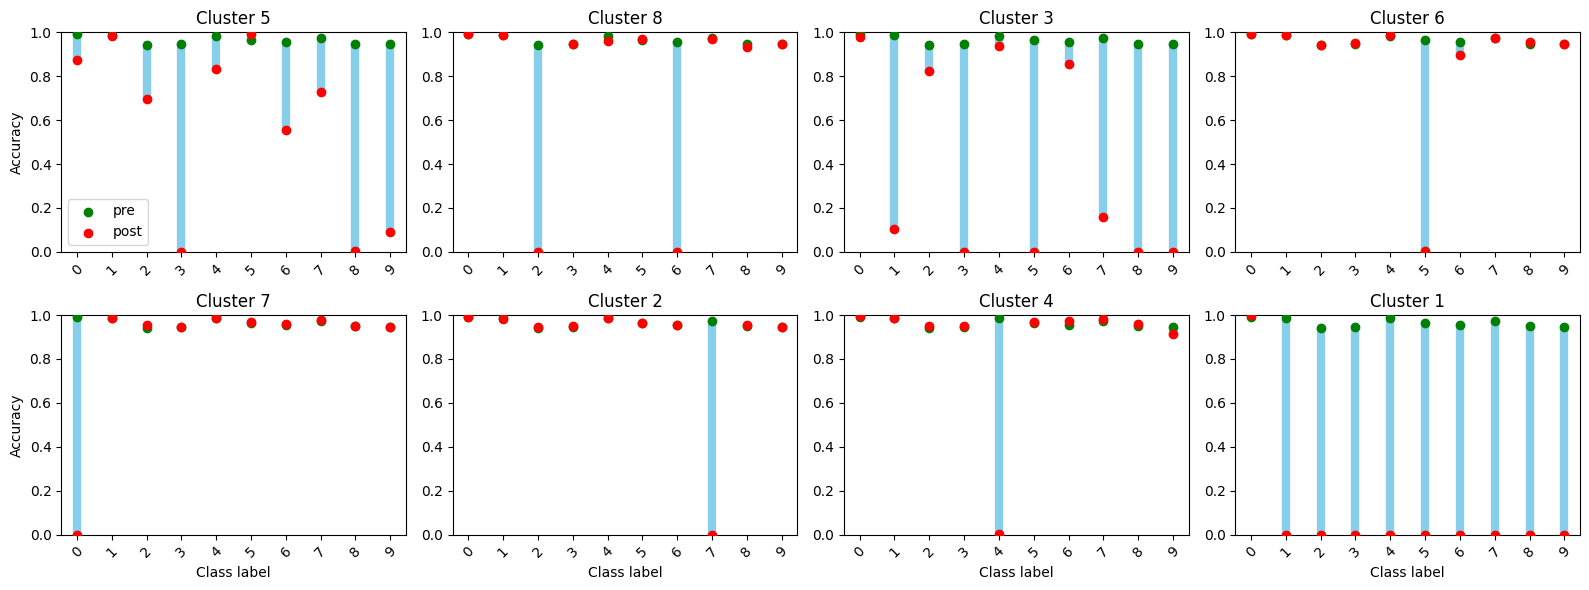

In [46]:
cluster_class_changes = plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))